# 1. Thư viện

In [262]:
import os
import re
import nltk
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from collections import Counter
from nltk.tokenize import word_tokenize
from pathlib import Path
from sklearn.model_selection import  train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lengo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 2. Tải và gộp Data thành 1 file csv

In [263]:
def create_imdb_csv(pos_folder, neg_folder, output_file):
    data = []

    # Danh sách các nguồn dữ liệu cần xử lý: (đường dẫn, nhãn)
    sources = [
        (pos_folder, 1), # Label 1 cho Positive
        (neg_folder, 0)  # Label 0 cho Negative
    ]
    
    print(f"Đang xử lý để tạo file: {output_file}...")
    
    for folder_path, label in sources:
        path_obj = Path(folder_path)
        
        # Kiểm tra thư mục có tồn tại không
        if not path_obj.exists():
            print(f"Cảnh báo: Không tìm thấy thư mục {folder_path}")
            continue
            
        files = list(path_obj.glob("*.txt"))
        
        for file in files:
            try:
                with open(file, 'r', encoding='utf-8') as f:
                    content = f.read().strip()
                data.append({"text": content, "label": label})
            except Exception as e:
                print(f"Lỗi đọc file {file.name}: {e}")

    # Gộp và lưu thành csv
    if not data:
        print("Không tìm thấy dữ liệu hợp lệ nào.")
        return None
    else:
        df = pd.DataFrame(data)
        # Xáo trộn dữ liệu (Shuffle)
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        
        # Lưu file
        df.to_csv(output_file, index=False, encoding='utf-8-sig')
        
        # In thống kê
        print(f"-> Đã tạo xong file: {output_file}")
        print(f"   Tổng số mẫu: {len(df):,}")
        print(f"   Positive (1): {len(df[df['label']==1]):,}")
        print(f"   Negative (0): {len(df[df['label']==0]):,}")
        print("-" * 30)
        
        return df

In [264]:
# 1.Tập Train
df_train_val = pd.read_csv("train.csv")

# 2. Tập Test
df_test = pd.read_csv("test.csv")

In [265]:
df_train_val.head (5)

,text,label
0,In Panic In The Streets Richard Widmark plays ...,1
1,If you ask me the first one was really better ...,0
2,I am a big fan a Faerie Tale Theatre and I've ...,1
3,I just finished reading a book about Dillinger...,0
4,Greg Davis and Bryan Daly take some crazed sta...,0


In [266]:
df_test.head (5)

,text,label
0,"When I was a kid, I loved ""Tiny Toons"". I espe...",1
1,"The setup for ""Nature of the Beast"" is ingenio...",0
2,I do not have much to say than this is a great...,1
3,Extremely formulaic with cosmic-sized logic ho...,0
4,I actually liked certain things about this gam...,0


# 3. Làm sạch dữ liệu

In [267]:
stop_words = set(stopwords.words('english')) - {'not', 'but', 'very'}
def preprocess_text(text):
    # 1. Remove HTML tags 
    text = re.sub(r'<[^>]+>', '', text)

    # 2. Convert to LowerCase 
    text = text.lower()
    
    # 3. Remove All Punctuation
    # [^\w\s] sẽ giữ lại chữ, số và khoảng trắng, loại bỏ dấu câu
    text = re.sub(r'[^\w\s]', '', text) 
    
    # 4. Tokenize (Split by Space)
    tokens = text.split() 
    
    # 5. Remove stopwords
    processed_tokens = [w for w in tokens if w not in stop_words]
    
    return processed_tokens

# 4. Xây dựng bộ từ điển ánh xạ

In [268]:
def build_vocab(data, min_freq = 50):
    word_counts = Counter()
    for text in data:
        word_counts.update (text)
        
    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word, count in word_counts.items():
        if count >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

In [269]:
#Xây dựng lại Vocab từ cột đã xử lý (đảm bảo tính nhất quán)
processed_train_texts = [preprocess_text(text) for text in tqdm(df_train_val['text'])]

word2idx = build_vocab(processed_train_texts)
vocab_size = len(word2idx)
print(f"Kích thước từ điển: {vocab_size:,} từ")

  0%|          | 0/25000 [00:00<?, ?it/s]

Kích thước từ điển: 6,938 từ


# 5. Phân phối độ dài các bài review

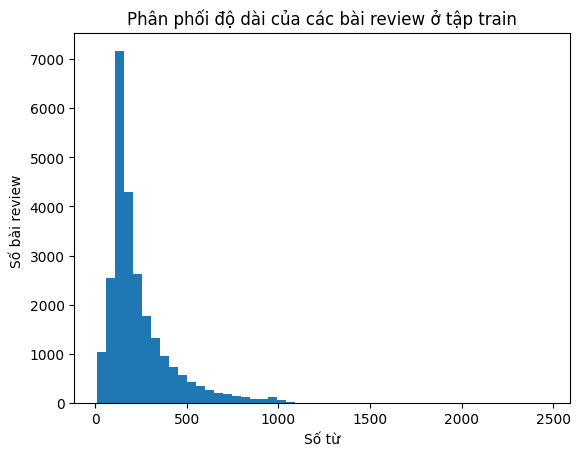

In [270]:
# Biểu đồ phân phối số từ trong các bài review
lengths = [len(t.split()) for t in df_train_val['text']]
plt.hist(lengths, bins=50)
plt.xlabel("Số từ")
plt.ylabel("Số bài review ")
plt.title("Phân phối độ dài của các bài review ở tập train")
plt.show()

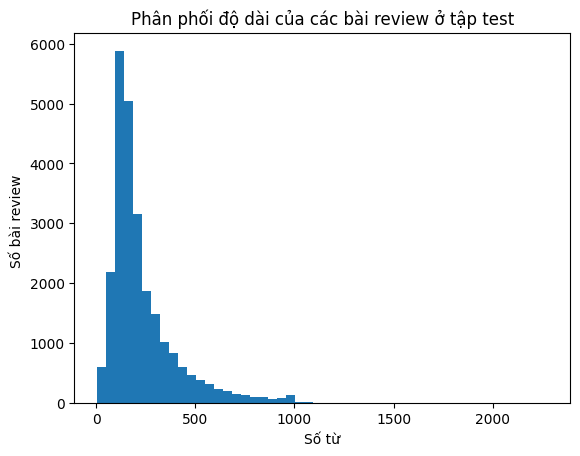

In [271]:
# Biểu đồ phân phối số từ trong các bài review
lengths = [len(t.split()) for t in df_test['text']]
plt.hist(lengths, bins=50)
plt.xlabel("Số từ")
plt.ylabel("Số bài review ")
plt.title("Phân phối độ dài của các bài review ở tập test")
plt.show()

# 5. Tạo Dataset cho IMDB

In [272]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_length):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_length = max_length
        self.stop_words = stop_words
    
    def __len__(self):
        return len(self.texts)
    
    def preprocess_text(self, text):
        text = re.sub(r'<[^>]+>', '', text)
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        tokens = text.split()
        processed_tokens = [w for w in tokens if w not in self.stop_words]
        return processed_tokens
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        processed_tokens = self.preprocess_text(text)
        
        # Chuyển thành index
        indexed_tokens = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in processed_tokens]
        
        # Pad or truncate
        if len(indexed_tokens) < self.max_length:
            # Pad with <PAD> token (index 0)
            padded_tokens = indexed_tokens + [self.word2idx['<PAD>']] * (self.max_length - len(indexed_tokens))
        else:
            # Truncate
            padded_tokens = indexed_tokens[:self.max_length]
            
        return torch.tensor(padded_tokens, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# 6. Chia train / validation và tạo DataLoader

In [273]:
MAX_LENGTH = 200
BATCH_SIZE = 128

# 1. Chia tập dữ liệu 
df_train, df_val = train_test_split(df_train_val, test_size=0.3, random_state=42, stratify=df_train_val['label'])

# 2. Khởi tạo Dataset
train_dataset = IMDBDataset(df_train['text'].tolist(), df_train['label'].tolist(), word2idx, MAX_LENGTH)
val_dataset = IMDBDataset(df_val['text'].tolist(), df_val['label'].tolist(), word2idx, MAX_LENGTH)
test_dataset = IMDBDataset(df_test['text'].tolist(), df_test['label'].tolist(), word2idx, MAX_LENGTH)

# 3. Tạo DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [274]:
print(f"Số batch train: {len(train_loader)}")
print(f"Số batch validation: {len(val_loader)}")
print(f"Số batch test: {len(test_loader)}")
print(f"Kích thước tập train: {len(train_dataset):,} mẫu")
print(f"Kích thước tập val: {len(val_dataset):,} mẫu")
print(f"Kích thước tập test: {len(test_dataset):,} mẫu")

Số batch train: 137
Số batch validation: 59
Số batch test: 196
Kích thước tập train: 17,500 mẫu
Kích thước tập val: 7,500 mẫu
Kích thước tập test: 25,000 mẫu


# 7. Định nghĩa mô hình LSTM

In [275]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, padding_idx):
        super().__init__()
        
        # 1. Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        
        # 2. LSTM layer (Bidirectional)
        self.lstm = nn.LSTM(embedding_dim, 
                            hidden_dim, 
                            num_layers=n_layers, 
                            bidirectional=False, 
                            dropout=dropout if n_layers > 1 else 0, 
                            batch_first=True)
        
        # 3. Dropout layer
        self.dropout = nn.Dropout(dropout)
        
        # 4. Linear layer - Vì là một chiều nên chỉ cần hidden_dim
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text_batch):
        # text_batch: [BATCH_SIZE, MAX_LENGTH]
        # 1. Embedding
        embedded = self.embedding(text_batch) 
        
        # 2. LSTM
        # hidden shape: [num_layers, batch, hidden_dim]
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # 3. Lấy trạng thái ẩn cuối cùng của tầng cuối cùng
        # Với batch_first=True, hidden state có shape [n_layers, batch, hidden_dim]
        # Ta lấy hidden[-1] là trạng thái ẩn của lớp trên cùng
        final_hidden = hidden[-1,:, :] # Shape: [batch, hidden_dim]
        
        # 4. Dropout và Linear Layer
        out = self.dropout(final_hidden)
        out = self.fc(out)
        
        return out.squeeze(1)

# 8. Train model

In [276]:
# Chọn thiết bị
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Training on Device {DEVICE}")

# Cấu hình các tham số cho mô hình SentimentLSTM
EMBEDDING_DIM = 100
HIDDEN_DIM = 256
N_LAYERS = 2      
OUTPUT_DIM = 1    
DROPOUT = 0.5  

# Khởi tạo mô hình
model = LSTM(vocab_size=len(word2idx),
                      embedding_dim=EMBEDDING_DIM,
                      hidden_dim=HIDDEN_DIM, 
                      output_dim=OUTPUT_DIM,
                      n_layers=N_LAYERS, 
                      dropout=DROPOUT,
                      padding_idx=word2idx['<PAD>'])

# Chuyển mô hình lên thiết bị (GPU/CPU)
model = model.to(DEVICE)

Training on Device cpu


In [277]:
# Đầu vào huấn luyện mô hình
epochs = 15
optimizer = optim.Adam(params=model.parameters(), lr=0.003)
loss_fn = nn.BCEWithLogitsLoss()
def train(model, device, epochs, optimizer, loss_fn, train_loader, val_loader):
    log_training = {"epoch": [],
                    "training_loss": [],
                    "training_acc": [],
                    "validation_loss":[],
                    "validation_acc": []}
    
    for epoch in range(1, epochs + 1):
            print(f"Starting Epoch {epoch}")
            model.train()
            training_losses, training_accuracies = [], []
            
            for text, label in tqdm(train_loader):
                text, label = text.to(device), label.to(device).float()
                
                optimizer.zero_grad()
                out = model(text) # out shape [batch_size]
                
                loss = loss_fn(out, label)
                training_losses.append(loss.item())
                
                # Tính Accuracy cho Logits: Nếu out > 0 thì dự đoán là 1, ngược lại là 0
                preds = (out > 0).int() 
                accuracy = (preds == label.int()).float().mean()
                training_accuracies.append(accuracy.item())
                
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
    
            model.eval()
            val_losses, val_accuracies = [], []
            with torch.no_grad():
                for text, label in tqdm(val_loader):
                    text, label = text.to(device), label.to(device).float()
                    out = model(text)
                    
                    loss = loss_fn(out, label)
                    val_losses.append(loss.item())
                    
                    preds = (out > 0).int()
                    accuracy = (preds == label.int()).float().mean()
                    val_accuracies.append(accuracy.item())
                
            training_loss_mean, training_acc_mean = np.mean(training_losses), np.mean(training_accuracies)
            valid_loss_mean, valid_acc_mean = np.mean(val_losses), np.mean(val_accuracies)
        
            log_training["epoch"].append(epoch)
            log_training["training_loss"].append(training_loss_mean)
            log_training["training_acc"].append(training_acc_mean)
            log_training["validation_loss"].append(valid_loss_mean)
            log_training["validation_acc"].append(valid_acc_mean)

            print("Training Loss:", training_loss_mean) 
            print("Training Acc:", training_acc_mean)
            print("Validation Loss:", valid_loss_mean)
            print("Validation Acc:", valid_acc_mean)
    
    return log_training, model

In [278]:
training_logging, model = train(model=model,
                                device=DEVICE,
                                epochs=epochs,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                train_loader=train_loader,
                                val_loader=val_loader)

Starting Epoch 1


  0%|          | 0/137 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

Training Loss: 0.6938684969922922
Training Acc: 0.5008900944333877
Validation Loss: 0.6916488984883842
Validation Acc: 0.5151371541669814
Starting Epoch 2


  0%|          | 0/137 [00:00<?, ?it/s]

...

  0%|          | 0/59 [00:00<?, ?it/s]

Training Loss: 0.045550804520637665
Training Acc: 0.9901469771879433
Validation Loss: 0.6288251942497188
Validation Acc: 0.8445584299200672
Starting Epoch 15


  0%|          | 0/137 [00:00<?, ?it/s]

  0%|          | 0/59 [00:00<?, ?it/s]

Training Loss: 0.04055897444894496
Training Acc: 0.9914808791049206
Validation Loss: 0.722454696388568
Validation Acc: 0.8411992636777587


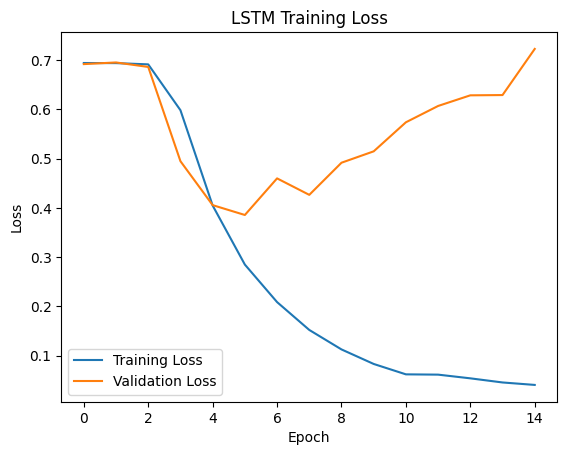

In [279]:
plt.plot(training_logging["training_loss"], label="Training Loss")
plt.plot(training_logging["validation_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

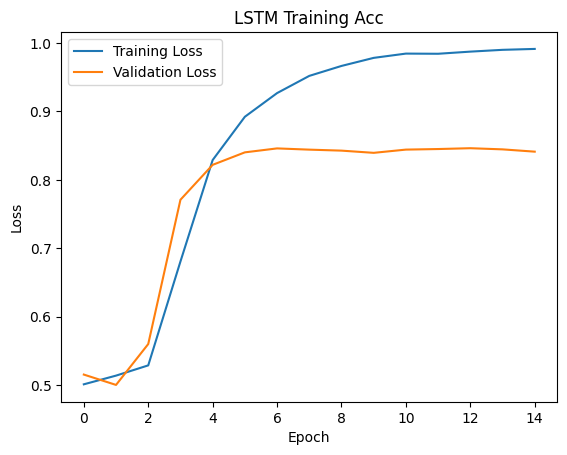

In [280]:
plt.plot(training_logging["training_acc"], label="Training Loss")
plt.plot(training_logging["validation_acc"], label="Validation Loss")
plt.title("LSTM Training Acc")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 9. Đánh giá mô hình

In [281]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
test_loss = 0.0
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(DEVICE)
        logits = model(inputs)
        
        # Chuyển logits thành 0 hoặc 1
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int() 
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = accuracy_score(all_labels, all_preds)

print(f'Test Loss: {avg_test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')
print("\nClassification Report:")
# 0 is negative, 1 is positive
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

  0%|          | 0/196 [00:00<?, ?it/s]

Test Loss: 0.000 | Test Acc: 82.85%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.86      0.83     12500
    Positive       0.85      0.80      0.82     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



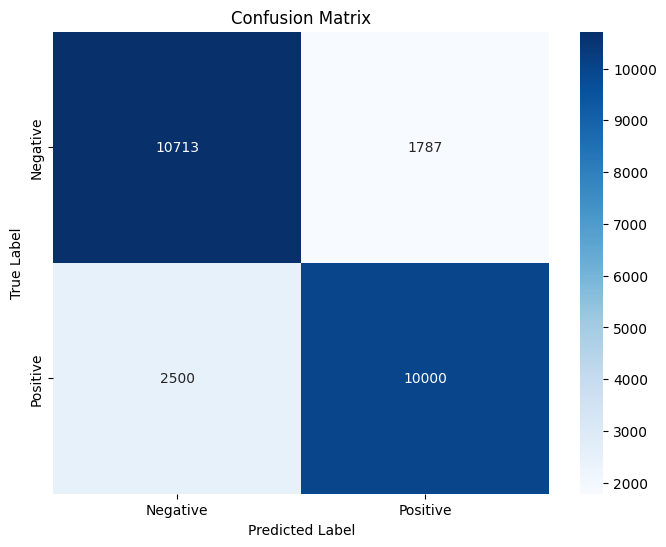

In [282]:
# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(all_labels, all_preds)

# Hiển thị ma trận nhầm lẫn bằng heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 10. Dự đoán thực tế trên dữ liệu mới

In [283]:
def predict_sentiment(review, model, word2idx, max_length, device):
    model.eval()
    
    # 1. Xử lý văn bản (Sử dụng hàm preprocess_text đã định nghĩa ở Cell 40)
    tokens = preprocess_text(review)
    
    # 2. Chuyển từ thành index
    sequence = [
        word2idx.get(word, word2idx['<UNK>']) 
        for word in tokens
    ]
    
    # 3. Padding hoặc Cắt ngắn
    if len(sequence) < max_length:
        sequence += [word2idx['<PAD>']] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]
        
    # 4. Chuyển thành Tensor và đưa vào Device
    # input shape cần là [1, MAX_LENGTH] (batch_size = 1)
    input_tensor = torch.tensor(sequence, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # 5. Lấy output từ model
        logit = model(input_tensor) # Kết quả là một số thực (vd: 2.5 hoặc -1.3)
        
        # 6. Dùng Sigmoid để chuyển thành xác suất (0 -> 1)
        probability = torch.sigmoid(logit).item()
        
    print(f"Câu review: {review}")
    print(f"Xác suất tích cực (Positive probability): {probability:.4f}")
    
    # 7. Đặt ngưỡng 0.5 để quyết định
    sentiment = "Positive" if probability >= 0.5 else "Negative"
    return sentiment

In [284]:
review_text = "This movie is absolutely wonderful and fantastic!"
result = predict_sentiment(review_text, model, word2idx, MAX_LENGTH, DEVICE)
print(f"Dự đoán: {result}")

Câu review: This movie is absolutely wonderful and fantastic!
Xác suất tích cực (Positive probability): 0.9965
Dự đoán: Positive


# 11. Thử nghiệm trên một số kiến trúc khác

## Bidirectional

## GRU